In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import lightgbm as lgb
import xgboost as xgb

Training set shape: (614, 8) (614,)
Test set shape: (154, 8) (154,)


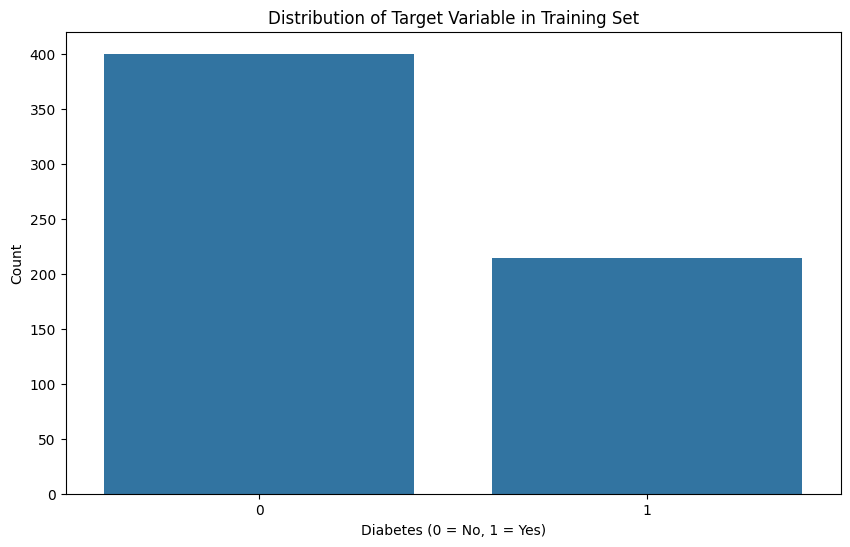

In [5]:
X_train = pd.read_csv("../data/preprocessed/pima_preprocessed/pima_X_train_scaled.csv")
y_train = pd.read_csv("../data/preprocessed/pima_preprocessed/pima_y_train.csv").values.ravel()
X_test = pd.read_csv("../data/preprocessed/pima_preprocessed/pima_X_test_scaled.csv")
y_test = pd.read_csv("../data/preprocessed/pima_preprocessed/pima_y_test.csv").values.ravel()

print("Training set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)

plt.figure(figsize=(10, 6))
sns.countplot(x=y_train)
plt.title("Distribution of Target Variable in Training Set")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

c:\Users\kiero\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Resampled training set shape: (800, 8) (800,)


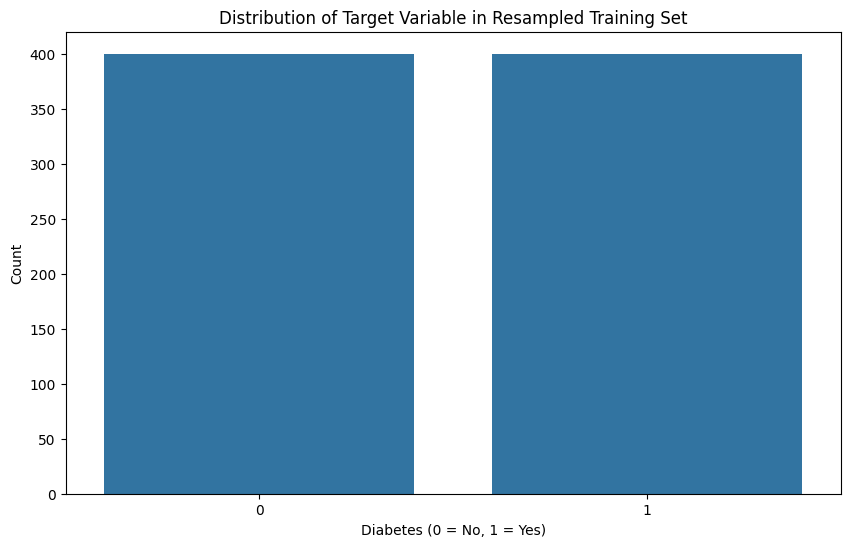

In [6]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("Resampled training set shape:", X_train_resampled.shape, y_train_resampled.shape)
plt.figure(figsize=(10, 6))
sns.countplot(x=y_train_resampled)
plt.title("Distribution of Target Variable in Resampled Training Set")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [8]:
def evaluate_model(name, y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f"\n{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    
    if y_prob is not None:
        auc = roc_auc_score(y_true, y_prob)
        print(f"AUC-ROC  : {auc:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
lr.fit(X_train_resampled, y_train_resampled)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]
evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)



Logistic Regression
Accuracy : 0.7143
Precision: 0.5806
Recall   : 0.6667
F1-score : 0.6207
AUC-ROC  : 0.8113

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.58      0.67      0.62        54

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.70       154
weighted avg       0.73      0.71      0.72       154

